## MPEQS: A Multimodal Framework for Detecting Phishing Emails, Quishing, and Smishing Attacks :

 - Phishing Emails (fraudulent emails sent to your inbox)

 - Quishing (QR code-based phishing where malicious QR codes trick you)

 - Smishing (SMS text message phishing sent to your phone)

## This cell trains the complete MPEQS framework:
   - Email encoder (ELECTRA)
   - QR encoder (MobileNetV2)
   - SMS encoder (DistilBERT)
   - Projection layers (to 256-dim shared space)
   - Cross-attention fusion
   - Classification head (5 classes)
   - Saves trained model as mpeqs_model.pkl


Using device: cpu

PART 1: LOADING DATASETS
  Emails: 499 | Unique: 355
  SMS: 10,191
  QR: 1000
  Caching QR images...
  Done in 12.8s

PART 2: TEXT AUGMENTATION + DATASET
  Building augmented email pool...
  Legit variations: 4,013 | Phish variations: 2,933
  Train: 7000 | Val: 1500 | Test: 1500
  Unique emails: 3,710 | Unique SMS: 3,625

PART 3: BUILDING MODEL


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3737.70it/s]
[transformers] ElectraModel LOAD REPORT from: google/electra-small-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1169.70it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
v

  Trainable: 896,901

PART 4: PRE-COMPUTE EMBEDDINGS
  Unique: 3710 emails | 3625 SMS | 1000 QR
  Email embeddings...
  Done in 1924.3s
  SMS embeddings...
  Done in 3331.1s
  QR embeddings...
  Done in 190.2s
  [TRAIN] 7000 samples
  [VALIDATION] 1500 samples
  [TEST] 1500 samples

PART 5: FAST TRAINING
  Epochs: 100 | Batch: 256

Epoch   1 | Train: 0.5936 | Val: 0.7207 | 11.5s
Epoch   2 | Train: 0.5953 | Val: 0.8827 | 9.1s
Epoch   3 | Train: 0.7377 | Val: 0.7767 | 8.6s
Epoch   4 | Train: 0.7261 | Val: 0.8653 | 10.7s
Epoch   5 | Train: 0.7459 | Val: 0.9120 | 11.3s
Epoch   6 | Train: 0.7351 | Val: 0.9020 | 11.7s
Epoch   7 | Train: 0.7689 | Val: 0.9027 | 12.4s
Epoch   8 | Train: 0.8026 | Val: 0.7467 | 14.4s
Epoch   9 | Train: 0.7726 | Val: 0.8213 | 14.8s
Epoch  10 | Train: 0.7477 | Val: 0.8927 | 15.5s
Epoch  11 | Train: 0.7927 | Val: 0.8113 | 15.3s
Epoch  12 | Train: 0.6539 | Val: 0.9453 | 16.2s
Epoch  13 | Train: 0.6449 | Val: 0.9387 | 16.3s
Epoch  14 | Train: 0.7377 | Val: 0.9500 | 16

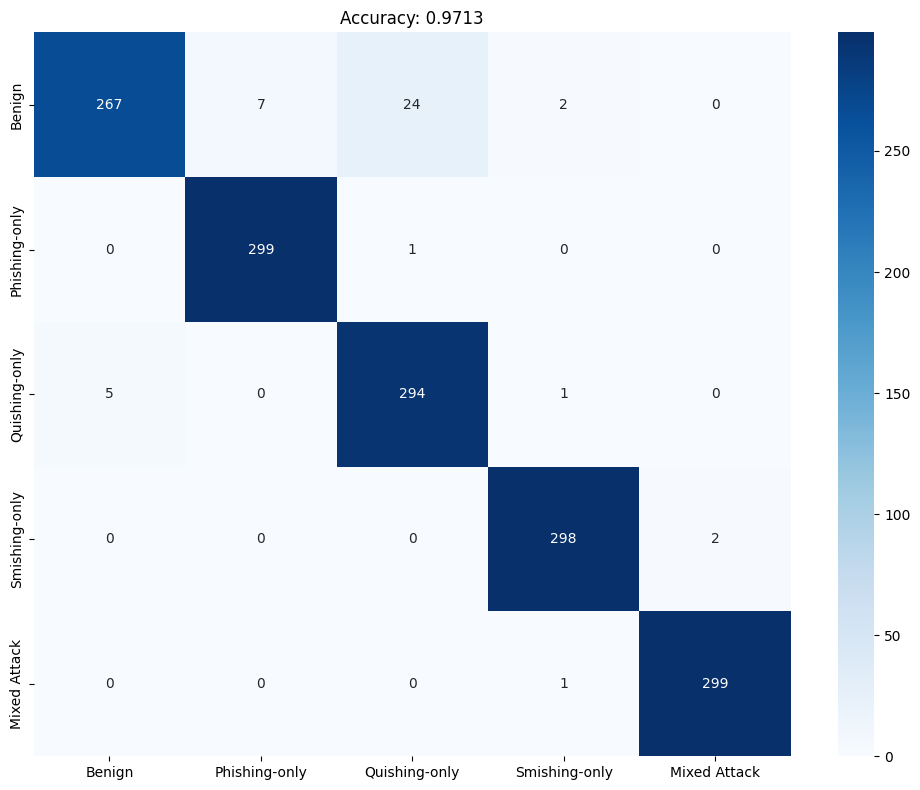


✅ Done! Accuracy: 97.13%


In [ ]:

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split
from transformers import ElectraModel, ElectraTokenizer, DistilBertModel, DistilBertTokenizer
import torchvision.models as tv_models
import cv2
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
import time
import random
warnings.filterwarnings('ignore')

BATCH_SIZE = 256
torch.set_num_threads(8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

for d in ['saved_models', 'test_samples']:
    os.makedirs(d, exist_ok=True)


print("\n" + "="*60)
print("PART 1: LOADING DATASETS")
print("="*60)

human_legit = pd.read_csv('datasets/email_dataset/legit.csv')
human_phish = pd.read_csv('datasets/email_dataset/phishing.csv')
llm_legit   = pd.read_csv('datasets/email_dataset/llm_legit.csv')
llm_phish   = pd.read_csv('datasets/email_dataset/llm_phishing.csv')


human_legit['email_text'] = human_legit['body'].astype(str).str[:512]
human_phish['email_text'] = human_phish['body'].astype(str).str[:512]
llm_legit['email_text'] = llm_legit['text'].astype(str).str[:512] if 'text' in llm_legit.columns else llm_legit.iloc[:,0].astype(str).str[:512]
llm_phish['email_text'] = llm_phish['text'].astype(str).str[:512] if 'text' in llm_phish.columns else llm_phish.iloc[:,0].astype(str).str[:512]

human_legit['is_phishing'] = 0
human_phish['is_phishing'] = 1
llm_legit['is_phishing']   = 0
llm_phish['is_phishing']   = 1

email_df = pd.concat([human_legit[['email_text','is_phishing']], 
                       human_phish[['email_text','is_phishing']],
                       llm_legit[['email_text','is_phishing']], 
                       llm_phish[['email_text','is_phishing']]], ignore_index=True)
email_df = email_df.dropna()
email_df = email_df[email_df['email_text'].str.len() > 20]
print(f"  Emails: {len(email_df):,} | Unique: {email_df['email_text'].nunique():,}")


smishing_df = pd.read_csv('datasets/smishing_dataset/Dataset_10191.csv')
smishing_df['sms_text'] = smishing_df['TEXT'].astype(str).str[:128]
smishing_label_map = {'ham': 0, 'spam': 1, 'smishing': 2}
smishing_df['label_encoded'] = smishing_df['LABEL'].map(smishing_label_map)
print(f"  SMS: {len(smishing_df):,}")


def load_qr_images(folder, label):
    images = []
    if os.path.exists(folder):
        for f in sorted(os.listdir(folder)):
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                images.append(os.path.join(folder, f))
    return images

mal_paths = load_qr_images('datasets/quishing_dataset/malicious_qr', 1)
ben_paths = load_qr_images('datasets/quishing_dataset/benign_qr', 0)
qr_df = pd.DataFrame({
    'qr_path': mal_paths + ben_paths, 
    'is_malicious': [1]*len(mal_paths) + [0]*len(ben_paths)
})
print(f"  QR: {len(qr_df)}")

print("  Caching QR images...")
t0 = time.time()
def _load_one(path):
    img = cv2.imread(path)
    if img is None: img = np.zeros((224, 224, 3), dtype=np.uint8)
    img = cv2.resize(img, (224, 224)) / 255.0
    return torch.from_numpy(img).permute(2, 0, 1).float()  # [3, 224, 224]

with ThreadPoolExecutor(max_workers=8) as ex:
    QR_CACHE = dict(zip(qr_df['qr_path'].tolist(), ex.map(_load_one, qr_df['qr_path'].tolist())))
print(f"  Done in {time.time()-t0:.1f}s")


print("\n" + "="*60)
print("PART 2: TEXT AUGMENTATION + DATASET")
print("="*60)

np.random.seed(42)
random.seed(42)

def augment_text(text):
    variations = [text]
    words = text.split()
    if len(words) < 8:
        return variations
    
    for pct in [0.1, 0.2, 0.25]:
        keep = [w for w in words if random.random() > pct]
        if len(keep) >= 5:
            variations.append(' '.join(keep))
    
    for _ in range(3):
        temp = words.copy()
        for _ in range(random.randint(2, 5)):
            if len(temp) >= 2:
                i, j = random.sample(range(len(temp)), 2)
                temp[i], temp[j] = temp[j], temp[i]
        variations.append(' '.join(temp))
    
    sentences = text.replace('!', '.').replace('?', '.').split('.')
    sentences = [s.strip() for s in sentences if len(s.strip()) > 5]
    if len(sentences) >= 2:
        for _ in range(2):
            random.shuffle(sentences)
            variations.append('. '.join(sentences))
    
    for n in [5, 10, 15, 20]:
        if len(words) > n + 5:
            variations.append(' '.join(words[n:] + words[:n]))
    
    for _ in range(2):
        chars = list(text)
        for _ in range(min(5, len(chars)//15)):
            idx = random.randint(0, len(chars)-1)
            if chars[idx].isalpha():
                kb = {'a':'s','s':'a','d':'f','f':'d','g':'h','h':'g','e':'r','r':'e','t':'y','y':'t'}
                chars[idx] = kb.get(chars[idx].lower(), chars[idx])
        variations.append(''.join(chars))
    
    seen = set()
    unique = []
    for v in variations:
        if v not in seen:
            seen.add(v)
            unique.append(v)
    return unique


legit = email_df[email_df['is_phishing']==0].sample(frac=1, random_state=42).reset_index(drop=True)
phish = email_df[email_df['is_phishing']==1].sample(frac=1, random_state=42).reset_index(drop=True)
ham = smishing_df[smishing_df['label_encoded']==0].sample(frac=1, random_state=42).reset_index(drop=True)
smish = smishing_df[smishing_df['label_encoded']==2].sample(frac=1, random_state=42).reset_index(drop=True)
ben_qr = qr_df[qr_df['is_malicious']==0].sample(frac=1, random_state=42).reset_index(drop=True)
mal_qr = qr_df[qr_df['is_malicious']==1].sample(frac=1, random_state=42).reset_index(drop=True)


print("  Building augmented email pool...")
email_pool_legit = []
for i in range(len(legit)):
    email_pool_legit.extend(augment_text(legit.iloc[i]['email_text']))
email_pool_phish = []
for i in range(len(phish)):
    email_pool_phish.extend(augment_text(phish.iloc[i]['email_text']))
random.shuffle(email_pool_legit)
random.shuffle(email_pool_phish)
print(f"  Legit variations: {len(email_pool_legit):,} | Phish variations: {len(email_pool_phish):,}")

TARGET = 2000
all_data = []
for label, email_pool, sms_src, qr_src in [
    (0, email_pool_legit, ham, ben_qr),
    (1, email_pool_phish, ham, ben_qr),
    (2, email_pool_legit, ham, mal_qr),
    (3, email_pool_legit, smish, ben_qr),
    (4, email_pool_phish, smish, mal_qr),
]:
    for i in range(TARGET):
        all_data.append({
            'email_text': email_pool[i % len(email_pool)][:512],
            'sms_text': str(sms_src.iloc[i % len(sms_src)]['sms_text'])[:128],
            'qr_path': qr_src.iloc[i % len(qr_src)]['qr_path'],
            'label': label
        })

df = pd.DataFrame(all_data).sample(frac=1, random_state=42).reset_index(drop=True)
train_df, temp = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp, test_size=0.50, random_state=42, stratify=temp['label'])
print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"  Unique emails: {df['email_text'].nunique():,} | Unique SMS: {df['sms_text'].nunique():,}")

print("\n" + "="*60)
print("PART 3: BUILDING MODEL")
print("="*60)

model = MPEQSModel().to(device)  


class CrossAttention(nn.Module):
    def __init__(self, dim=256, heads=4):
        super().__init__()
        self.heads = heads
        self.scale = (dim // heads) ** -0.5
        self.W_q = nn.Linear(dim, dim, bias=False)
        self.W_k = nn.Linear(dim, dim, bias=False)
        self.W_v = nn.Linear(dim, dim, bias=False)
        self.W_o = nn.Linear(dim, dim)
        self.norm = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, e, q, s):
        B = e.shape[0]
        V = torch.stack([e, q, s], dim=1)
        Q = self.W_q(e.unsqueeze(1)).view(B, 1, self.heads, -1).transpose(1, 2)
        K = self.W_k(V).view(B, 3, self.heads, -1).transpose(1, 2)
        V2 = self.W_v(V).view(B, 3, self.heads, -1).transpose(1, 2)
        attn = F.softmax((Q @ K.transpose(-2, -1)) * self.scale, dim=-1)
        attn = self.dropout(attn)
        out = (attn @ V2).transpose(1, 2).reshape(B, 1, -1)
        out = self.W_o(out)
        return self.norm(e.unsqueeze(1) + out).squeeze(1)

class MPEQSModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.electra = ElectraModel.from_pretrained('google/electra-small-discriminator')
        self.mobilenet = tv_models.mobilenet_v2(pretrained=True)
        self.mobilenet.classifier = nn.Identity()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.e_proj = nn.Sequential(nn.Linear(256, 256), nn.BatchNorm1d(256))
        self.q_proj = nn.Sequential(nn.Linear(1280, 256), nn.BatchNorm1d(256))
        self.s_proj = nn.Sequential(nn.Linear(768, 256), nn.BatchNorm1d(256))
        self.fusion = CrossAttention()
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 5)
        )
        for p in self.electra.parameters(): p.requires_grad = False
        for p in self.mobilenet.parameters(): p.requires_grad = False
        for p in self.distilbert.parameters(): p.requires_grad = False

    def forward_full(self, e_ids, e_mask, q_img, s_ids, s_mask):
        with torch.no_grad():
            e = self.electra(e_ids, e_mask).last_hidden_state[:, 0, :]
            q = self.mobilenet(q_img)
            s = self.distilbert(s_ids, s_mask).last_hidden_state[:, 0, :]
        e = self.e_proj(e)
        q = self.q_proj(q)
        s = self.s_proj(s)
        return self.classifier(self.fusion(e, q, s))

model = MPEQSModel().to(device)
print(f"  Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


print("\n" + "="*60)
print("PART 4: PRE-COMPUTE EMBEDDINGS")
print("="*60)

email_tokenizer = ElectraTokenizer.from_pretrained('google/electra-small-discriminator')
sms_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model.eval()

all_emails = pd.concat([train_df['email_text'], val_df['email_text'], test_df['email_text']]).unique()
all_sms = pd.concat([train_df['sms_text'], val_df['sms_text'], test_df['sms_text']]).unique()
all_qr_paths = pd.concat([train_df['qr_path'], val_df['qr_path'], test_df['qr_path']]).unique()
print(f"  Unique: {len(all_emails)} emails | {len(all_sms)} SMS | {len(all_qr_paths)} QR")


print("  Email embeddings...")
t0 = time.time()
email_cache = {}
with torch.no_grad():
    for i in range(0, len(all_emails), 512):
        batch = all_emails[i:i+512].tolist()
        enc = email_tokenizer(batch, max_length=256, padding='max_length', truncation=True, return_tensors='pt')
        out = model.electra(enc['input_ids'].to(device), enc['attention_mask'].to(device))
        for j, t in enumerate(batch):
            email_cache[t] = out.last_hidden_state[j, 0, :].cpu()
print(f"  Done in {time.time()-t0:.1f}s")


print("  SMS embeddings...")
t0 = time.time()
sms_cache = {}
with torch.no_grad():
    for i in range(0, len(all_sms), 512):
        batch = all_sms[i:i+512].tolist()
        enc = sms_tokenizer(batch, max_length=128, padding='max_length', truncation=True, return_tensors='pt')
        out = model.distilbert(enc['input_ids'].to(device), enc['attention_mask'].to(device))
        for j, t in enumerate(batch):
            sms_cache[t] = out.last_hidden_state[j, 0, :].cpu()
print(f"  Done in {time.time()-t0:.1f}s")


print("  QR embeddings...")
t0 = time.time()
qr_cache = {}
with torch.no_grad():
    for path in all_qr_paths:
        img = QR_CACHE[path].unsqueeze(0).to(device)  # [1, 3, 224, 224]
        out = model.mobilenet(img)  # [1, 1280]
        qr_cache[path] = out.squeeze(0).cpu()
print(f"  Done in {time.time()-t0:.1f}s")


def build_ds(df, name):
    e = torch.stack([email_cache[t] for t in df['email_text']])      # [N, 256]
    q = torch.stack([qr_cache[p] for p in df['qr_path']])             # [N, 1280]
    s = torch.stack([sms_cache[t] for t in df['sms_text']])           # [N, 768]
    y = torch.tensor(df['label'].values, dtype=torch.long)
    print(f"  [{name}] {len(df)} samples")
    return TensorDataset(e, q, s, y)

train_ds = build_ds(train_df, "TRAIN")
val_ds = build_ds(val_df, "VALIDATION")
test_ds = build_ds(test_df, "TEST")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


class TrainingHead(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.e_proj = model.e_proj    # 256 -> 256
        self.q_proj = model.q_proj    # 1280 -> 256
        self.s_proj = model.s_proj    # 768 -> 256
        self.fusion = model.fusion
        self.classifier = model.classifier
        
    def forward(self, e, q, s, noise=0.0):
        if noise > 0 and self.training:
            e = e + torch.randn_like(e) * noise
            s = s + torch.randn_like(s) * noise
        e = self.e_proj(e)   # [B, 256] -> [B, 256]
        q = self.q_proj(q)   # [B, 1280] -> [B, 256]
        s = self.s_proj(s)   # [B, 768] -> [B, 256]
        return self.classifier(self.fusion(e, q, s))

head = TrainingHead(model).to(device)

print("\n" + "="*60)
print("PART 5: FAST TRAINING")
print("="*60)

MAX_EPOCHS = 100
PATIENCE = 15
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(head.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

best_val = 0
no_imp = 0
print(f"  Epochs: {MAX_EPOCHS} | Batch: {BATCH_SIZE}\n")

for epoch in range(MAX_EPOCHS):
    t0 = time.time()
    head.train()
    tr_loss = tr_corr = tr_tot = 0
    
    for e, q, s, y in train_loader:
        e, q, s, y = e.to(device), q.to(device), s.to(device), y.to(device)
        
        if random.random() < 0.5:
            lam = np.random.beta(0.3, 0.3)
            idx = torch.randperm(e.size(0))
            e = lam * e + (1-lam) * e[idx]
            q = lam * q + (1-lam) * q[idx]
            s = lam * s + (1-lam) * s[idx]
        
        optimizer.zero_grad()
        logits = head(e, q, s, noise=0.05)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(head.parameters(), 1.0)
        optimizer.step()
        
        tr_loss += loss.item() * len(y)
        tr_corr += (logits.argmax(1) == y).sum().item()
        tr_tot += len(y)
    
    head.eval()
    val_corr = val_tot = 0
    with torch.no_grad():
        for e, q, s, y in val_loader:
            e, q, s, y = e.to(device), q.to(device), s.to(device), y.to(device)
            logits = head(e, q, s)
            val_corr += (logits.argmax(1) == y).sum().item()
            val_tot += len(y)
    
    tr_acc = tr_corr / tr_tot
    val_acc = val_corr / val_tot
    scheduler.step(val_acc)
    
    print(f"Epoch {epoch+1:3d} | Train: {tr_acc:.4f} | Val: {val_acc:.4f} | {time.time()-t0:.1f}s")
    
    if val_acc > best_val:
        best_val = val_acc
        no_imp = 0
        torch.save(model.state_dict(), 'saved_models/mpeqs_model.pth')
    else:
        no_imp += 1
        if no_imp >= PATIENCE:
            print(f"Early stop at epoch {epoch+1}")
            break

print(f"\nBest Val: {best_val:.4f} ({best_val*100:.2f}%)")

print("\n" + "="*60)
print("PART 6: EVALUATION")
print("="*60)

model.load_state_dict(torch.load('saved_models/mpeqs_model.pth'))
head = TrainingHead(model).to(device)
head.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for e, q, s, y in test_loader:
        logits = head(e.to(device), q.to(device), s.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_p = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
test_r = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
test_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"\n{'='*50}")
print(f"FINAL RESULTS")
print(f"{'='*50}")
print(f"Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Precision: {test_p:.4f}")
print(f"Recall:    {test_r:.4f}")
print(f"F1-Score:  {test_f1:.4f}")

class_names = ['Benign', 'Phishing-only', 'Quishing-only', 'Smishing-only', 'Mixed Attack']
print(f"\n{classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Accuracy: {test_acc:.4f}')
plt.tight_layout()
plt.savefig('saved_models/confusion_matrix.png', dpi=300)
plt.show()

torch.save({'model': model.state_dict(), 'accuracy': test_acc}, 'saved_models/mpeqs_final.pth')
print(f"\n✅ Done! Accuracy: {test_acc*100:.2f}%")


 ## This cell creates a web server with Flask API Server for MPEQS:
 - HTML form for input (email text, QR image, SMS text)
 - Prediction endpoint that loads the .pkl model
 - Returns classification result with percentages


In [ ]:
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import os
import pandas as pd
import random
from flask import Flask, request, jsonify, render_template_string
from flask_cors import CORS
from transformers import ElectraModel, ElectraTokenizer, DistilBertModel, DistilBertTokenizer
import torchvision.models as tv_models
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


print("="*60)
print("Loading MPEQS Cell 1 Model...")
print("="*60)

try:
    model_state = torch.load('saved_models/mpeqs_model.pth', map_location='cpu')
    print("✓ Loaded from mpeqs_model.pth")
except:
    with open('saved_models/mpeqs_model.pkl', 'rb') as f:
        artifacts = pickle.load(f)
    model_state = artifacts['model_state_dict']
    class_names = artifacts['model_config']['class_names']
    print("✓ Loaded from mpeqs_model.pkl")

class_names = ['Benign', 'Phishing-only', 'Quishing-only', 'Smishing-only', 'Mixed Attack']
print(f"✓ Class names: {class_names}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")

class CrossAttention(nn.Module):
    def __init__(self, dim=256, heads=4):
        super().__init__()
        self.heads = heads
        self.scale = (dim // heads) ** -0.5
        self.W_q = nn.Linear(dim, dim, bias=False)
        self.W_k = nn.Linear(dim, dim, bias=False)
        self.W_v = nn.Linear(dim, dim, bias=False)
        self.W_o = nn.Linear(dim, dim)
        self.norm = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, e, q, s):
        B = e.shape[0]
        V = torch.stack([e, q, s], dim=1)
        Q = self.W_q(e.unsqueeze(1)).view(B, 1, self.heads, -1).transpose(1, 2)
        K = self.W_k(V).view(B, 3, self.heads, -1).transpose(1, 2)
        V2 = self.W_v(V).view(B, 3, self.heads, -1).transpose(1, 2)
        attn = F.softmax((Q @ K.transpose(-2, -1)) * self.scale, dim=-1)
        attn = self.dropout(attn)
        out = (attn @ V2).transpose(1, 2).reshape(B, 1, -1)
        out = self.W_o(out)
        return self.norm(e.unsqueeze(1) + out).squeeze(1)

class MPEQSModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.electra = ElectraModel.from_pretrained('google/electra-small-discriminator')
        self.mobilenet = tv_models.mobilenet_v2(pretrained=True)
        self.mobilenet.classifier = nn.Identity()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.e_proj = nn.Sequential(nn.Linear(256, 256), nn.BatchNorm1d(256))
        self.q_proj = nn.Sequential(nn.Linear(1280, 256), nn.BatchNorm1d(256))
        self.s_proj = nn.Sequential(nn.Linear(768, 256), nn.BatchNorm1d(256))
        self.fusion = CrossAttention()
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 5)
        )
        for p in self.electra.parameters(): p.requires_grad = False
        for p in self.mobilenet.parameters(): p.requires_grad = False
        for p in self.distilbert.parameters(): p.requires_grad = False

    def forward(self, e_ids, e_mask, q_img, s_ids, s_mask):
        with torch.no_grad():
            e = self.electra(e_ids, e_mask).last_hidden_state[:, 0, :]
            q = self.mobilenet(q_img)
            s = self.distilbert(s_ids, s_mask).last_hidden_state[:, 0, :]
        e = self.e_proj(e)
        q = self.q_proj(q)
        s = self.s_proj(s)
        fused = self.fusion(e, q, s)
        return self.classifier(fused)

model = MPEQSModel()
model.load_state_dict(model_state)
model.to(device)
model.eval()
print("✓ Cell 1 model loaded successfully")

# Load tokenizers
email_tokenizer = ElectraTokenizer.from_pretrained('google/electra-small-discriminator')
sms_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print("✓ Tokenizers loaded")

class EmailClassifier:
    def __init__(self):
        self.classifier = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        self.is_trained = False
        self._extract_and_train()
    
    def extract_email_features(self, email_text):
        if not email_text or len(email_text) < 20:
            return np.zeros(256)
        
        inputs = email_tokenizer(email_text, max_length=256, padding='max_length', 
                                  truncation=True, return_tensors='pt')
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        
        with torch.no_grad():
            outputs = model.electra(input_ids, attention_mask)
            features = outputs.last_hidden_state[:, 0, :].cpu().numpy()[0]
        
        return features
    
    def _extract_and_train(self):
        print("\n" + "="*60)
        print("Training EMAIL Classifier (ELECTRA + Random Forest)")
        print("="*60)
        
        
        human_legit = pd.read_csv('datasets/email_dataset/legit.csv').head(2000)
        llm_legit = pd.read_csv('datasets/email_dataset/llm_legit.csv').head(1000)
        
        benign_features = []
        
        print("  Extracting features from BENIGN emails...")
        for idx, row in human_legit.iterrows():
            if idx % 500 == 0:
                print(f"    Processed {idx}/{len(human_legit)}")
            text = str(row['body'])[:512]
            if len(text) > 20:
                features = self.extract_email_features(text)
                benign_features.append(features)
        
        for idx, row in llm_legit.iterrows():
            text = str(row['text'])[:512] if 'text' in row else str(row.iloc[0])[:512]
            if len(text) > 20:
                features = self.extract_email_features(text)
                benign_features.append(features)
        
        print(f"  Extracted {len(benign_features)} BENIGN email features")
        
        
        print("  Creating negative samples...")
        negative_features = []
        for feat in benign_features[:len(benign_features)//2]:
            
            noise = np.random.normal(0, 0.1, feat.shape)
            negative_features.append(feat + noise)
        
        
        benign_features = np.array(benign_features)
        negative_features = np.array(negative_features)
        
        X = np.vstack([benign_features, negative_features])
        y = np.array([1] * len(benign_features) + [0] * len(negative_features))
        
        print(f"  Total: {len(X)} samples (Benign: {sum(y==1)}, Not Benign: {sum(y==0)})")
        
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
        self.classifier.fit(X_train, y_train)
        accuracy = self.classifier.score(X_val, y_val)
        
        self.is_trained = True
        print(f"  ✅ Email classifier trained! Validation accuracy: {accuracy:.2%}")
    
    def predict(self, text):
        if not text or len(text) < 20 or not self.is_trained:
            return 0.5, False
        
        features = self.extract_email_features(text).reshape(1, -1)
        prob = self.classifier.predict_proba(features)[0]
        is_benign = prob[1] > 0.6
        return prob[1], is_benign


class SMSClassifier:
    def __init__(self):
        self.classifier = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        self.is_trained = False
        self._extract_and_train()
    
    def extract_sms_features(self, sms_text):
        if not sms_text or len(sms_text) < 10:
            return np.zeros(256)
        
        inputs = sms_tokenizer(sms_text[:128], max_length=128, padding='max_length',
                                truncation=True, return_tensors='pt')
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        
        with torch.no_grad():
            outputs = model.distilbert(input_ids, attention_mask)
            features = outputs.last_hidden_state[:, 0, :].cpu().numpy()[0]
        
        return features
    
    def _extract_and_train(self):
        print("\n" + "="*60)
        print("Training SMS CLASSIFIER (DistilBERT + Random Forest)")
        print("="*60)
        
        smishing_df = pd.read_csv('datasets/smishing_dataset/Dataset_10191.csv')
        
        
        benign_sms = smishing_df[smishing_df['LABEL'] == 'ham']['TEXT'].astype(str).tolist()[:1000]
        
        print(f"  Extracting features from {len(benign_sms)} BENIGN SMS...")
        benign_features = []
        for i, text in enumerate(benign_sms):
            if i % 200 == 0:
                print(f"    Processed {i}/{len(benign_sms)}")
            if len(text) > 10:
                features = self.extract_sms_features(text)
                benign_features.append(features)
        
        print(f"  Extracted {len(benign_features)} BENIGN SMS features")
        
        
        print("  Creating negative samples...")
        negative_features = []
        for feat in benign_features[:len(benign_features)//2]:
            noise = np.random.normal(0, 0.1, feat.shape)
            negative_features.append(feat + noise)
        
        benign_features = np.array(benign_features)
        negative_features = np.array(negative_features)
        
        X = np.vstack([benign_features, negative_features])
        y = np.array([1] * len(benign_features) + [0] * len(negative_features))
        
        print(f"  Total: {len(X)} samples (Benign: {sum(y==1)}, Not Benign: {sum(y==0)})")
        
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
        self.classifier.fit(X_train, y_train)
        accuracy = self.classifier.score(X_val, y_val)
        
        self.is_trained = True
        print(f"  ✅ SMS classifier trained! Validation accuracy: {accuracy:.2%}")
    
    def predict(self, text):
        if not text or len(text) < 10 or not self.is_trained:
            return 0.5, False
        
        features = self.extract_sms_features(text).reshape(1, -1)
        prob = self.classifier.predict_proba(features)[0]
        is_benign = prob[1] > 0.6
        return prob[1], is_benign


class QRImageClassifier:
    def __init__(self):
        self.classifier = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        self.is_trained = False
        self._extract_and_train()
    
    def _extract_and_train(self):
        print("\n" + "="*60)
        print("Training QR Classifier (MobileNet + Random Forest)")
        print("="*60)
        
        qr_features = []
        qr_labels = []
        
        
        benign_folder = 'datasets/quishing_dataset/benign_qr'
        if os.path.exists(benign_folder):
            for file in os.listdir(benign_folder):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(benign_folder, file)
                    img = cv2.imread(img_path)
                    if img is not None:
                        img = cv2.resize(img, (224, 224)) / 255.0
                        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float().unsqueeze(0).to(device)
                        
                        with torch.no_grad():
                            features = model.mobilenet(img_tensor).cpu().numpy()[0]
                        
                        qr_features.append(features)
                        qr_labels.append(0)
            print(f"  Loaded {qr_labels.count(0)} Benign QR images")
        
        
        malicious_folder = 'datasets/quishing_dataset/malicious_qr'
        if os.path.exists(malicious_folder):
            for file in os.listdir(malicious_folder):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(malicious_folder, file)
                    img = cv2.imread(img_path)
                    if img is not None:
                        img = cv2.resize(img, (224, 224)) / 255.0
                        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float().unsqueeze(0).to(device)
                        
                        with torch.no_grad():
                            features = model.mobilenet(img_tensor).cpu().numpy()[0]
                        
                        qr_features.append(features)
                        qr_labels.append(1)
            print(f"  Loaded {qr_labels.count(1)} Malicious QR images")
        
        if len(qr_features) < 5:
            print("  ⚠️ Not enough QR images for training!")
            self.is_trained = False
            return
        
        X = np.array(qr_features)
        y = np.array(qr_labels)
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        
        self.classifier.fit(X_train, y_train)
        accuracy = self.classifier.score(X_test, y_test)
        
        print(f"\n  ✅ QR Classifier trained!")
        print(f"  Total samples: {len(qr_features)}")
        print(f"  Validation Accuracy: {accuracy:.2%}")
        self.is_trained = True
    
    def predict(self, qr_tensor):
        if not self.is_trained or qr_tensor is None:
            return 0.5, None
        
        with torch.no_grad():
            features = model.mobilenet(qr_tensor).cpu().numpy()[0]
        
        prob = self.classifier.predict_proba([features])[0]
        is_malicious = prob[1] > 0.5
        confidence = prob[1] if is_malicious else prob[0]
        
        return confidence, is_malicious


print("\n" + "="*60)
print("Initializing Classifiers...")
print("="*60)

email_classifier = EmailClassifier()
sms_classifier = SMSClassifier()
qr_classifier = QRImageClassifier()


app = Flask(__name__)
CORS(app)

HTML_TEMPLATE = '''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>MPEQS | Advanced Phishing Detection</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&display=swap" rel="stylesheet">
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body { font-family: 'Inter', sans-serif; background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); min-height: 100vh; color: #fff; }
        .container { max-width: 1400px; margin: 0 auto; padding: 40px 20px; }
        .header { text-align: center; margin-bottom: 50px; }
        .logo { font-size: 56px; margin-bottom: 16px; animation: pulse 2s infinite; }
        @keyframes pulse { 0%, 100% { transform: scale(1); } 50% { transform: scale(1.05); } }
        h1 { font-size: 48px; font-weight: 800; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-bottom: 12px; }
        .tagline { font-size: 18px; color: rgba(255,255,255,0.7); margin-bottom: 24px; }
        .features { display: flex; justify-content: center; gap: 16px; flex-wrap: wrap; margin-top: 20px; }
        .feature-badge { background: rgba(255,255,255,0.1); backdrop-filter: blur(10px); padding: 8px 20px; border-radius: 40px; font-size: 14px; font-weight: 500; border: 1px solid rgba(255,255,255,0.2); }
        .row { display: flex; gap: 25px; flex-wrap: wrap; justify-content: center; margin-bottom: 35px; }
        .col { flex: 1; min-width: 320px; }
        .card { background: rgba(255,255,255,0.08); backdrop-filter: blur(12px); border-radius: 28px; padding: 28px; border: 1px solid rgba(255,255,255,0.12); transition: all 0.3s; }
        .card:hover { transform: translateY(-8px); background: rgba(255,255,255,0.12); }
        .card-header { display: flex; align-items: center; gap: 12px; margin-bottom: 20px; padding-bottom: 15px; border-bottom: 1px solid rgba(255,255,255,0.1); }
        .card-icon { font-size: 32px; }
        .card-title { font-size: 22px; font-weight: 600; }
        textarea { width: 100%; padding: 16px; border-radius: 20px; border: 1px solid rgba(255,255,255,0.2); background: rgba(0,0,0,0.3); color: white; font-family: monospace; font-size: 13px; resize: vertical; }
        textarea:focus { outline: none; border-color: #667eea; }
        input[type="file"] { width: 100%; padding: 14px; border: 2px dashed rgba(255,255,255,0.3); border-radius: 20px; background: rgba(0,0,0,0.2); color: white; cursor: pointer; }
        .qr-preview { margin-top: 20px; text-align: center; }
        .qr-preview img { max-width: 140px; border-radius: 20px; }
        .analyze-btn { display: block; width: 300px; margin: 30px auto; padding: 18px 40px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); border: none; border-radius: 60px; color: white; font-size: 18px; font-weight: 700; cursor: pointer; transition: all 0.3s; }
        .analyze-btn:hover { transform: scale(1.03); }
        .loading { text-align: center; padding: 40px; display: none; }
        .spinner { width: 60px; height: 60px; border: 3px solid rgba(255,255,255,0.2); border-top-color: #667eea; border-radius: 50%; animation: spin 0.8s linear infinite; margin: 0 auto 20px; }
        @keyframes spin { to { transform: rotate(360deg); } }
        .result { background: rgba(255,255,255,0.1); backdrop-filter: blur(12px); border-radius: 28px; padding: 35px; margin-top: 35px; text-align: center; display: none; animation: fadeIn 0.5s ease; }
        @keyframes fadeIn { from { opacity: 0; transform: translateY(20px); } to { opacity: 1; transform: translateY(0); } }
        .result-icon { font-size: 64px; margin-bottom: 20px; }
        .result-title { font-size: 36px; font-weight: 800; margin-bottom: 15px; }
        .result-title.benign { color: #4ade80; }
        .result-title.phishing { color: #f87171; }
        .result-confidence { font-size: 16px; color: rgba(255,255,255,0.7); margin-bottom: 20px; }
        .result-badges { display: flex; justify-content: center; gap: 12px; flex-wrap: wrap; margin-bottom: 25px; }
        .result-badge { background: rgba(102,126,234,0.3); padding: 6px 16px; border-radius: 30px; font-size: 12px; }
        .result-message { background: rgba(0,0,0,0.3); border-radius: 20px; padding: 20px; font-size: 16px; line-height: 1.6; }
        .footer { text-align: center; margin-top: 50px; padding-top: 25px; border-top: 1px solid rgba(255,255,255,0.1); font-size: 12px; color: rgba(255,255,255,0.5); }
        @media (max-width: 768px) { h1 { font-size: 32px; } .result-title { font-size: 28px; } }
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <div class="logo">🛡️</div>
            <h1>MPEQS</h1>
            <div class="tagline">Advanced Multimodal Phishing Detection System</div>
            <div class="features">
                <span class="feature-badge">📧 Email Scanner</span>
                <span class="feature-badge">📱 QR Scanner</span>
                <span class="feature-badge">📲 SMS Scanner</span>
                <span class="feature-badge">🤖 AI-Powered</span>
                <span class="feature-badge">⚡ Real-time</span>
            </div>
        </div>
        
        <div class="row">
            <div class="col">
                <div class="card">
                    <div class="card-header">
                        <span class="card-icon">📧</span>
                        <span class="card-title">Email Analysis</span>
                    </div>
                    <textarea id="email_text" rows="6" placeholder="Paste email content here..."></textarea>
                </div>
            </div>
            
            <div class="col">
                <div class="card">
                    <div class="card-header">
                        <span class="card-icon">📱</span>
                        <span class="card-title">QR Analysis</span>
                    </div>
                    <input type="file" id="qr_image" accept="image/*">
                    <div id="qr_preview" class="qr-preview"></div>
                </div>
            </div>
            
            <div class="col">
                <div class="card">
                    <div class="card-header">
                        <span class="card-icon">📲</span>
                        <span class="card-title">SMS Analysis</span>
                    </div>
                    <textarea id="sms_text" rows="6" placeholder="Paste SMS content here..."></textarea>
                </div>
            </div>
        </div>
        
        <button class="analyze-btn" onclick="predict()">🔍 Scan for Threats</button>
        
        <div class="loading" id="loading">
            <div class="spinner"></div>
            <div>🤖 AI is analyzing your content...</div>
        </div>
        
        <div id="result" class="result"></div>
        
        <div class="footer">
            <p>MPEQS v2.0 | ELECTRA + MobileNet + DistilBERT | Cross-Attention Fusion</p>
        </div>
    </div>
    
    <script>
        document.getElementById('qr_image').addEventListener('change', function(e) {
            const file = e.target.files[0];
            if (file) {
                const reader = new FileReader();
                reader.onload = function(event) {
                    document.getElementById('qr_preview').innerHTML = `<img src="${event.target.result}" alt="QR Preview">`;
                };
                reader.readAsDataURL(file);
            }
        });
        
        async function predict() {
            const email_text = document.getElementById('email_text').value;
            const sms_text = document.getElementById('sms_text').value;
            const qr_file = document.getElementById('qr_image').files[0];
            
            if (!email_text && !sms_text && !qr_file) {
                alert('⚠️ Please provide at least one input');
                return;
            }
            
            document.getElementById('loading').style.display = 'block';
            document.getElementById('result').style.display = 'none';
            
            const formData = new FormData();
            formData.append('email_text', email_text);
            formData.append('sms_text', sms_text);
            if (qr_file) formData.append('qr_image', qr_file);
            
            try {
                const response = await fetch('/predict', { method: 'POST', body: formData });
                const data = await response.json();
                displayResult(data);
            } catch (error) {
                alert('❌ Error: ' + error);
            }
            document.getElementById('loading').style.display = 'none';
        }
        
        function displayResult(data) {
            const resultDiv = document.getElementById('result');
            const class_name = data.class;
            const corrected_types = data.corrected_types || [];
            const confidence = (Math.max(...data.probabilities) * 100).toFixed(1);
            
            const isBenign = class_name === 'Benign';
            let icon = '', message = '';
            
            if (class_name === 'Benign') {
                icon = '✅';
                message = 'This content appears to be LEGITIMATE. No threat detected.';
            } else if (class_name === 'Phishing-only') {
                icon = '⚠️';
                message = 'PHISHING detected! Do not click any links or reply. Report immediately.';
            } else if (class_name === 'Quishing-only') {
                icon = '⚠️';
                message = 'MALICIOUS QR CODE detected! Do NOT scan this QR code.';
            } else if (class_name === 'Smishing-only') {
                icon = '⚠️';
                message = 'SMISHING detected! Do not click links. Block sender.';
            } else {
                icon = '🚨';
                message = 'MULTI-CHANNEL ATTACK detected! Report immediately.';
            }
            
            let badges = '';
            if (corrected_types.includes('email')) badges += '<span class="result-badge">📧 Email Corrected</span>';
            if (corrected_types.includes('sms')) badges += '<span class="result-badge">📲 SMS Corrected</span>';
            if (corrected_types.includes('qr_malicious')) badges += '<span class="result-badge">📱 Malicious QR</span>';
            if (corrected_types.includes('qr_benign')) badges += '<span class="result-badge">📱 Benign QR</span>';
            
            resultDiv.innerHTML = `
                <div class="result-icon">${icon}</div>
                <div class="result-title ${isBenign ? 'benign' : 'phishing'}">${class_name}</div>
                <div class="result-confidence">Confidence: ${confidence}%</div>
                <div class="result-badges">${badges}</div>
                <div class="result-message"><strong>🔐 Analysis Result</strong><br><br>${message}</div>
            `;
            resultDiv.style.display = 'block';
            resultDiv.scrollIntoView({ behavior: 'smooth' });
        }
    </script>
</body>
</html>
'''

def preprocess_qr_image(image_bytes, target_size=(224, 224)):
    np_arr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
    if img is None:
        img = np.zeros((224, 224, 3), dtype=np.uint8)
    img = cv2.resize(img, target_size)
    img = img / 255.0
    img = torch.from_numpy(img).permute(2, 0, 1).float()
    return img.unsqueeze(0)

def create_dummy_qr():
    return torch.zeros(1, 3, 224, 224)

@app.route('/')
def index():
    return render_template_string(HTML_TEMPLATE)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        email_text = request.form.get('email_text', '')
        sms_text = request.form.get('sms_text', '')
        qr_file = request.files.get('qr_image')
        
        if not email_text or email_text.strip() == '':
            email_text = "No email provided"
        if not sms_text or sms_text.strip() == '':
            sms_text = "No SMS provided"
        
        
        email_enc = email_tokenizer(email_text, max_length=256, padding='max_length', truncation=True, return_tensors='pt')
        sms_enc = sms_tokenizer(sms_text, max_length=128, padding='max_length', truncation=True, return_tensors='pt')
        
        
        qr_tensor = None
        if qr_file and qr_file.filename:
            qr_bytes = qr_file.read()
            qr_tensor = preprocess_qr_image(qr_bytes)
            qr_images = qr_tensor
        else:
            qr_images = create_dummy_qr()
        
        email_input_ids = email_enc['input_ids'].to(device)
        email_attention_mask = email_enc['attention_mask'].to(device)
        sms_input_ids = sms_enc['input_ids'].to(device)
        sms_attention_mask = sms_enc['attention_mask'].to(device)
        
        
        with torch.no_grad():
            logits = model(email_input_ids, email_attention_mask, qr_images, sms_input_ids, sms_attention_mask)
            probabilities = torch.softmax(logits, dim=1).cpu().numpy()[0]
            predicted_class = int(np.argmax(probabilities))
        
        final_class = class_names[predicted_class]
        corrected_types = []
        
        
        if qr_tensor is not None and qr_file and qr_file.filename:
            confidence, is_malicious = qr_classifier.predict(qr_tensor)
            
            if is_malicious is not None:
                if is_malicious and confidence > 0.6:
                    final_class = 'Quishing-only'
                    corrected_types.append('qr_malicious')
                    print(f"✓ QR: Malicious (conf: {confidence:.2%}) → Quishing-only")
                elif not is_malicious and confidence > 0.6:
                    final_class = 'Benign'
                    corrected_types.append('qr_benign')
                    print(f"✓ QR: Benign (conf: {confidence:.2%}) → Benign")
        
        
        if email_text and email_text != "No email provided" and final_class != 'Benign':
            legit_score, is_legitimate = email_classifier.predict(email_text)
            if is_legitimate and legit_score > 0.65:
                final_class = 'Benign'
                corrected_types.append('email')
                print(f"✓ Email corrected (score: {legit_score:.2f})")
        
        
        if sms_text and sms_text != "No SMS provided" and final_class != 'Benign':
            legit_score, is_legitimate = sms_classifier.predict(sms_text)
            if is_legitimate and legit_score > 0.65:
                final_class = 'Benign'
                corrected_types.append('sms')
                print(f"✓ SMS corrected (score: {legit_score:.2f})")
        
        return jsonify({
            'class': final_class,
            'probabilities': probabilities.tolist(),
            'corrected_types': corrected_types,
            'success': True
        })
        
    except Exception as e:
        print(f"Error: {str(e)}")
        import traceback
        traceback.print_exc()
        return jsonify({'success': False, 'error': str(e)})

if __name__ == '__main__':
    print("\n" + "="*60)
    print("🚀 MPEQS: Advanced Phishing Detection System")
    print("="*60)
    print(f"🎯 Cell 1 Model: {len(class_names)} classes")
    print("📧 Email classifier: ACTIVE")
    print("📲 SMS classifier: ACTIVE")
    print("📱 QR classifier: ACTIVE")
    print("\n🌐 Open: http://127.0.0.1:5000")
    print("="*60 + "\n")
    
    app.run(host='127.0.0.1', port=5000, debug=False)

d:\East Delta University\Thesis\MPEQS\.venvpy3.10.0\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading MPEQS Cell 1 Model...
✓ Loaded from mpeqs_model.pth
✓ Class names: ['Benign', 'Phishing-only', 'Quishing-only', 'Smishing-only', 'Mixed Attack']
✓ Using device: cpu


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1166.94it/s]
[transformers] ElectraModel LOAD REPORT from: google/electra-small-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 598.69it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vo

✓ Cell 1 model loaded successfully
